In [4]:
import sys
sys.path.append('/Users/mariana/Documents/projects/Huawei/survan')

from utils import pad_sequences, get_single_task_dataset

In [5]:
import math

In [3]:
import os
import h5py
import numpy as np
import jax
import jax.numpy as jnp

data_path = '/Users/mariana/Documents/projects/Huawei/cloudproject/data/Delays/new_data_b03-09_online/'

# Initialize an empty list to collect arrays
arrays = []

for root, dirs, files in os.walk(data_path):
    for filename in files:
        if filename.endswith('.mat'):
            file_path = os.path.join(root, filename)
            with h5py.File(file_path, 'r') as f:
                if 'traces_self' in f:
                    size = f['traces_self'].shape[0]
                    # Extract the array under the 'traces_self' key
                    t_self = [f['traces_self'][i].reshape(-1, 39) for i in range(size)]
                    arrays.extend(t_self)

In [28]:
seqs, ts, cs = get_single_task_dataset(4, data_path, 100)

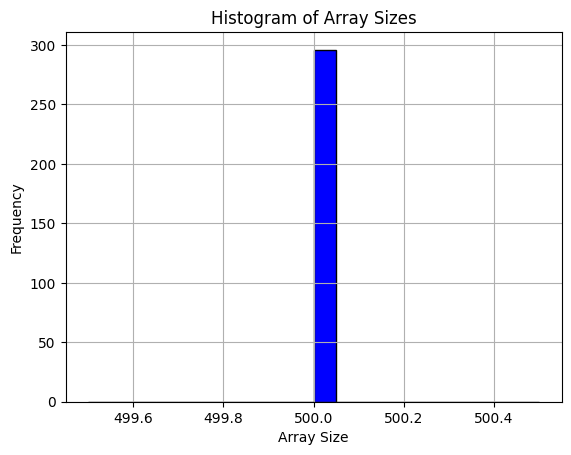

In [7]:
import matplotlib.pyplot as plt

# Assuming 'l' is your list of arrays
# Calculate the sizes (number of elements) of each array in 'l'
sizes = [len(arr) for arr in seqs]

# Create a histogram of the sizes
plt.hist(sizes, bins=20, color='blue', edgecolor='black')
plt.xlabel('Array Size')
plt.ylabel('Frequency')
plt.title('Histogram of Array Sizes')
plt.grid(True)

# Show the histogram
plt.show()


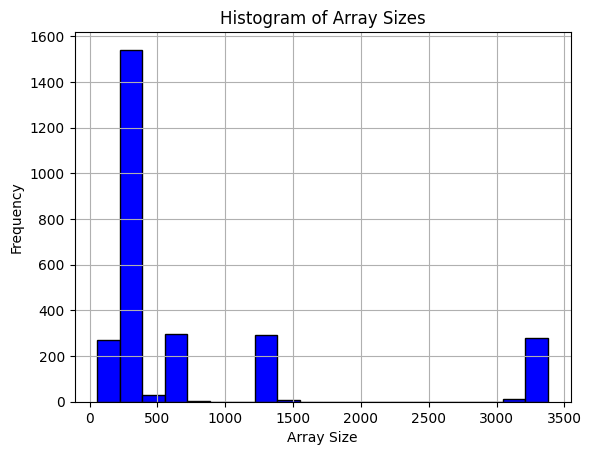

In [5]:
# Assuming 'l' is your list of arrays
# Calculate the sizes (number of elements) of each array in 'l'
sizes = np.array([len(arr) for arr in arrays])

# Calculate the mean and standard deviation of the sizes
mean_size = np.mean(sizes)
std_dev = np.std(sizes)

# Define a threshold for outliers (three times the standard deviation)
threshold = 3 * std_dev

# Filter out sizes that are more than three standard deviations away from the mean
filtered_sizes = [size for size in sizes if abs(size - mean_size) <= threshold]


# Create a histogram of the sizes
plt.hist(filtered_sizes, bins=20, color='blue', edgecolor='black')
plt.xlabel('Array Size')
plt.ylabel('Frequency')
plt.title('Histogram of Array Sizes')
plt.grid(True)

# Show the histogram
plt.show()


In [24]:
seqs.shape

(296, 1000, 39)

In [17]:
ts.shape

(1184,)

In [18]:
cs.shape

(1184,)

In [29]:
ts

Array([344, 244, 144, ..., 204, 104,   5], dtype=int32)